In [1]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
X1_obs = np.load("f1initial_inputs.npy")
y1_obs = np.load("f1initial_outputs.npy")
print("file shapes F1 ", X1_obs.shape, y1_obs.shape)

X2_obs = np.load("f2initial_inputs.npy")
y2_obs = np.load("f2initial_outputs.npy")
print("file shapes F2 ", X2_obs.shape, y2_obs.shape)

X3_obs = np.load("f3initial_inputs.npy")
y3_obs = np.load("f3initial_outputs.npy")
print("file shapes F3 ", X3_obs.shape, y3_obs.shape)

X4_obs = np.load("f4initial_inputs.npy")
y4_obs = np.load("f4initial_outputs.npy")
print("file shapes F4 ", X4_obs.shape, y4_obs.shape)

X5_obs = np.load("f5initial_inputs.npy")
y5_obs = np.load("f5initial_outputs.npy")
print("file shapes F5 ", X5_obs.shape, y5_obs.shape)

X6_obs = np.load("f6initial_inputs.npy")
y6_obs = np.load("f6initial_outputs.npy")
print("file shapes F6 ", X6_obs.shape, y6_obs.shape)

X7_obs = np.load("f7initial_inputs.npy")
y7_obs = np.load("f7initial_outputs.npy")
print("file shapes F7 ", X7_obs.shape, y7_obs.shape)

X8_obs = np.load("f8initial_inputs.npy")
y8_obs = np.load("f8initial_outputs.npy")
print("file shapes F8 ", X8_obs.shape, y8_obs.shape)


file shapes F1  (12, 2) (12,)
file shapes F2  (12, 2) (12,)
file shapes F3  (17, 3) (17,)
file shapes F4  (32, 4) (32,)
file shapes F5  (22, 4) (22,)
file shapes F6  (22, 5) (22,)
file shapes F7  (32, 6) (32,)
file shapes F8  (42, 8) (42,)


In [3]:
def expected_improvement(X, gp, y_best, xi=0.01, minimize=True):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    if minimize:
        improvement = y_best - mu - xi
    else:
        improvement = mu - y_best - xi

    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

In [4]:
def propose_next_point(X_obs, y_obs, bounds, n_candidates=5000):
    
    ei_tol=1e-6
    
    """
    Black-box Bayesian optimization (minimization)

    X_obs: (N, D)
    y_obs: (N,)
    bounds: list of (low, high), length D
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidates
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])

    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )

    # Best (minimum) observed value
    y_best = np.min(y_obs)

    # Expected Improvement for minimization
    ei = expected_improvement(
        X_candidates,
        gp,
        y_best,
        minimize=True
    )
    ei = np.asarray(ei).ravel()

    # "Good" points: expected improvement toward smaller values
    good_mask = ei > ei_tol

    if np.any(good_mask):
        idx = np.argmax(ei[good_mask])
        x_next = X_candidates[good_mask][idx]
    else:
        # Exploration fallback
        x_next = X_candidates[np.argmax(ei)]


    return x_next

In [5]:
def propose_next_point_ucb(
    X_obs,
    y_obs,
    bounds,
    n_candidates=5000,
    kappa=2.0
):
    """
    Bayesian Optimization proposal using UCB (minimization-safe)
    """

    X_obs = np.atleast_2d(X_obs)
    y_obs = np.asarray(y_obs).ravel()

    N, dim = X_obs.shape
    assert len(bounds) == dim, "Bounds must match dimensionality"

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=np.ones(dim)),
        alpha=1e-10,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Sample candidate points
    lows = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    X_candidates = np.random.uniform(
        low=lows,
        high=highs,
        size=(n_candidates, dim)
    )

    # Predict GP mean and std
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    # LCB = mean - kappa * std
    lcb = mu - kappa * sigma

    # Pick the candidate with lowest LCB
    idx = np.argmin(lcb)
    x_next = X_candidates[idx]

    return x_next


In [9]:
# F1 - new query point

bounds1 = [(0.0, 1.0), (0.0, 1.0)]

# x_EI_next1 = propose_next_point(X1_obs, y1_obs, bounds1)
# x_UCB_next1 = propose_next_point_ucb(X1_obs, y1_obs, bounds1)
# print("F1 Next query point EI and UCB :", x_EI_next1,x_UCB_next1)

x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.2
range_vec = np.array([b[1] - b[0] for b in bounds1])

for i in range(10):
    x_EI_next = propose_next_point(X1_obs, y1_obs, bounds1)
    x_UCB_next = propose_next_point_ucb(X1_obs, y1_obs, bounds1)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F1 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    


F1 agreed next query point: 9 True 0.1939288660476385 [0.369292 0.521566] [0.535916 0.422345]


In [159]:
# F2 - new query point

bounds2 = [(0.0, 1.0), (0.0, 1.0)]

# x_EI_next2 = propose_next_point(X2_obs, y2_obs, bounds2)
# x_UCB_next2 = propose_next_point_ucb(X2_obs, y2_obs, bounds2)
# print("F2 Next query point EI and UCB :", x_EI_next2,x_UCB_next2)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.2
range_vec = np.array([b[1] - b[0] for b in bounds2])

for i in range(10):
    x_EI_next = propose_next_point(X2_obs, y2_obs, bounds2)
    x_UCB_next = propose_next_point_ucb(X2_obs, y2_obs, bounds2)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F2 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        

F2 agreed next query point: 2 True 0.13857422039620945 [0.979034 0.388559] [0.899608 0.502112]
F2 agreed next query point: 8 True 0.10024845754978694 [0.001016 0.768214] [0.025518 0.865422]


In [196]:
bounds3 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0)]

# x_EI_next3 = propose_next_point(X3_obs, y3_obs, bounds3)
# x_UCB_next3 = propose_next_point_ucb(X3_obs, y3_obs, bounds3)

# print("F3 Next query point EI and UCB :", x_EI_next3,x_UCB_next3)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.2
range_vec = np.array([b[1] - b[0] for b in bounds3])

for i in range(10):
    x_EI_next = propose_next_point(X3_obs, y3_obs, bounds3)
    x_UCB_next = propose_next_point_ucb(X3_obs, y3_obs, bounds3)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F3 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        


F3 agreed next query point: 3 True 0.1859181570840952 [0.565065 0.233813 0.707861] [0.56049  0.126704 0.555965]


In [163]:
bounds4 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

# x_EI_next4 = propose_next_point(X4_obs, y4_obs, bounds4)
# x_UCB_next4 = propose_next_point_ucb(X4_obs, y4_obs, bounds4)

# print("F4 Next query point EI and UCB :", x_EI_next4,x_UCB_next4)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.25
range_vec = np.array([b[1] - b[0] for b in bounds4])

for i in range(40):
    x_EI_next = propose_next_point(X4_obs, y4_obs, bounds4)
    x_UCB_next = propose_next_point_ucb(X4_obs, y4_obs, bounds4)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F4 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    



F4 agreed next query point: 17 True 0.18641355328971498 [0.445518 0.099272 0.248701 0.895601] [0.284278 0.178112 0.273437 0.851739]


In [167]:
bounds5 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

# x_EI_next5 = propose_next_point(X5_obs, y5_obs, bounds5)
# x_UCB_next5 = propose_next_point_ucb(X5_obs, y5_obs, bounds5)

# print("F5 Next query point EI and UCB :", x_EI_next5,x_UCB_next5)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.2
range_vec = np.array([b[1] - b[0] for b in bounds5])

for i in range(40):
    x_EI_next = propose_next_point(X5_obs, y5_obs, bounds5)
    x_UCB_next = propose_next_point_ucb(X5_obs, y5_obs, bounds5)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F5 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
        



F5 agreed next query point: 33 True 0.1811927763363234 [0.704339 0.844687 0.327644 0.619848] [0.66911  0.9618   0.272438 0.498084]


In [185]:
bounds6 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

# x_EI_next6 = propose_next_point(X6_obs, y6_obs, bounds6)
# x_UCB_next6 = propose_next_point_ucb(X6_obs, y6_obs, bounds6)

# print("F6 Next query point EI and UCB :", x_EI_next6,x_UCB_next6)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.3
range_vec = np.array([b[1] - b[0] for b in bounds6])

for i in range(40):
    x_EI_next = propose_next_point(X6_obs, y6_obs, bounds6)
    x_UCB_next = propose_next_point_ucb(X6_obs, y6_obs, bounds6)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F6 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    



F6 agreed next query point: 26 True 0.1761553351345665 [0.901458 0.614056 0.476775 0.566322 0.473333] [0.898639 0.736437 0.585717 0.630066 0.462647]


In [192]:
bounds7 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0),(0.0, 1.0)]

# x_EI_next7 = propose_next_point(X7_obs, y7_obs, bounds7)
# x_UCB_next7 = propose_next_point_ucb(X7_obs, y7_obs, bounds7)

# print("F7 Next query point EI and UCB :", x_EI_next7,x_UCB_next7)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.5
range_vec = np.array([b[1] - b[0] for b in bounds7])

for i in range(40):
    x_EI_next = propose_next_point(X7_obs, y7_obs, bounds7)
    x_UCB_next = propose_next_point_ucb(X7_obs, y7_obs, bounds7)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F7 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    

F7 agreed next query point: 21 True 0.4622912689972736 [0.571935 0.042903 0.483963 0.189677 0.561965 0.609864] [0.753941 0.426218 0.626712 0.182663 0.674168 0.635168]
F7 agreed next query point: 24 True 0.33716727877856784 [0.399178 0.358514 0.187391 0.429437 0.24748  0.703227] [0.477722 0.630993 0.279747 0.343189 0.37783  0.685658]
F7 agreed next query point: 25 True 0.39774230876134015 [0.823887 0.612357 0.031235 0.347807 0.006259 0.143871] [0.893193 0.416813 0.034899 0.34261  0.306037 0.302774]


In [194]:
bounds8 = [(0.0, 1.0), (0.0, 1.0),(0.0, 1.0),(0.0, 1.0), (0.0,1.0), (0.0,1.0), (0.0,1.0),(0.0,1.0)]

# x_EI_next8 = propose_next_point(X8_obs, y8_obs, bounds8)
# x_UCB_next8 = propose_next_point_ucb(X8_obs, y8_obs, bounds8)

# print("F8 Next query point EI and UCB :", x_EI_next8,x_UCB_next8)
x_EI_next = None
x_UCB_next = None
x_ei_points = []
x_ucb_points = []
tol = 0.3
range_vec = np.array([b[1] - b[0] for b in bounds8])

for i in range(40):
    x_EI_next = propose_next_point(X8_obs, y8_obs, bounds8)
    x_UCB_next = propose_next_point_ucb(X8_obs, y8_obs, bounds8)
    x_ei_points.append(x_EI_next.ravel()[0])
    x_ucb_points.append(x_UCB_next.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next - x_UCB_next) / range_vec)
    agree = scaled_dist < tol
    if agree == True :
        print("F8 agreed next query point:",i, agree, np.linalg.norm(x_EI_next - x_UCB_next), np.round(x_EI_next,6),np.round(x_UCB_next,6))
    


F8 agreed next query point: 19 True 0.22568485266276997 [0.934939 0.972797 0.97472  0.895817 0.936722 0.323301 0.950795 0.110814] [0.99372  0.771243 0.992235 0.920083 0.87294  0.312518 0.980311 0.140868]


agree : 1 True 0.17174866913338754 [0.60434031 0.37164849] [0.43263096 0.3753229 ]


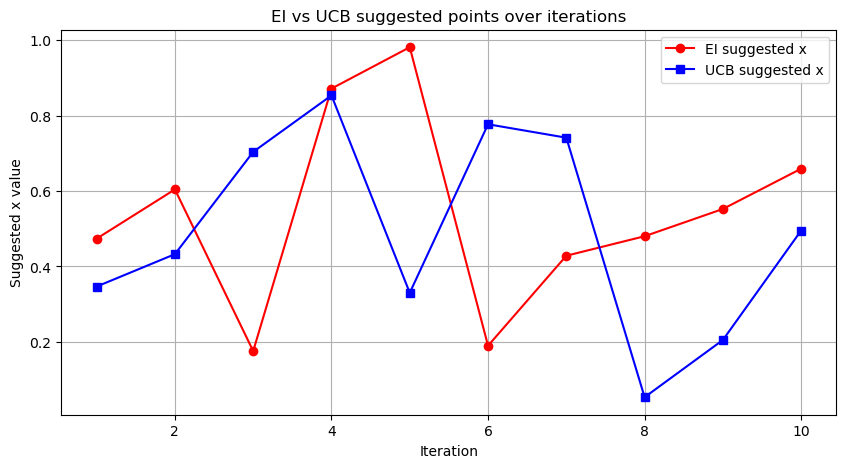

In [102]:
# F2 graph - to check 

x_ei_points = []
x_ucb_points = []

tol = 0.2
range_vec = np.array([b[1] - b[0] for b in bounds])

for i in range(10):
    x_EI_next2 = propose_next_point(X2_obs, y2_obs, bounds2)
    x_UCB_next2 = propose_next_point_ucb(X2_obs, y2_obs, bounds2)
    x_ei_points.append(x_EI_next2.ravel()[0])
    x_ucb_points.append(x_UCB_next2.ravel()[0])
    
    scaled_dist = np.linalg.norm((x_EI_next2 - x_UCB_next2) / range_vec)
    agree = scaled_dist < tol
    # agree = np.linalg.norm(x_EI_next2 - x_UCB_next2) < tol
    # print("agree :",i, agree, np.linalg.norm(x_EI_next2 - x_UCB_next2), x_EI_next2,x_UCB_next2)
    if agree == True :
         print("agree :",i, agree, np.linalg.norm(x_EI_next2 - x_UCB_next2), x_EI_next2,x_UCB_next2)
    #     print("Similar query point : Iteration, EI and UCB:", i, x_EI_next2,x_UCB_next2)

plt.figure(figsize=(10,5))
plt.plot(range(1,11), x_ei_points, 'r-o', label='EI suggested x')
plt.plot(range(1,11), x_ucb_points, 'b-s', label='UCB suggested x')
plt.xlabel('Iteration')
plt.ylabel('Suggested x value')
plt.title('EI vs UCB suggested points over iterations')
plt.legend()
plt.grid(True)
plt.show()


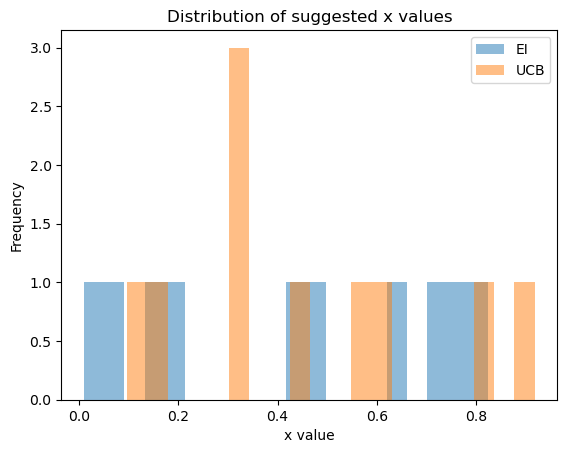

In [87]:
plt.hist(x_ei_points, bins=20, alpha=0.5, label='EI')
plt.hist(x_ucb_points, bins=20, alpha=0.5, label='UCB')
plt.xlabel('x value')
plt.ylabel('Frequency')
plt.title('Distribution of suggested x values')
plt.legend()
plt.show()

In [77]:
print(X1_obs)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.284551   0.668744  ]]


In [78]:
print(y1_obs)

[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -1.88477605e-056]
